In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from astropy.table import Table
import astropy.units as u

from crossmatching import Crossmatcher, EMCCatalog, NEACatalog, SimbadIdSupplier, EMCIdSupplier

mpl.rcParams['figure.dpi'] = 150


class EMCIdSupplierRaw(EMCIdSupplier):
    """Comparison-only variant: aliases matched exactly as stored, no prefix stripping."""

    def _expand_id_with_variants(self, input_id, id_str):
        return [(input_id, id_str.strip())]
    

# EMCIdSupplier._expand_id_with_variants = (lambda self, input_id, id_str: [(input_id, id_str)]) 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
input_table = Table.read('./input/HPIC_LC4_combined_d50.txt', format='ascii')
name_list = input_table['star_name'].tolist()
print(f'Input: {len(input_table):,} stars')

Input: 14,571 stars


## EMC catalog: SimbadIdSupplier vs EMCIdSupplier vs EMCIdSupplierRaw

- **SimbadIdSupplier**: queries SIMBAD TAP with each HPIC star name, returns all known aliases; cached in `alternate_ids_hpic.txt`
- **EMCIdSupplier**: reads `main_id_aliases` directly from the EMC CSV; expands SIMBAD prefixes (`*`, `NAME`, possessives) into additional match candidates
- **EMCIdSupplierRaw**: same as above but aliases are matched exactly as stored, no prefix stripping

All three are used against the same EMC catalog (`exo-mercat.csv`).

In [22]:
# EMC + SimbadIdSupplier
cm_emc_simbad = Crossmatcher(EMCCatalog(), SimbadIdSupplier())
cm_emc_simbad.load_catalog(from_file='./input/exo-mercat.csv', format='csv')
cm_emc_simbad.load_alternate_ids(name_list, from_file='./alternate_ids_hpic.txt')
out_emc_simbad = cm_emc_simbad.combined_crossmatch(input_table, input_starname_key='star_name')

# EMC + EMCIdSupplier (with alias expansion)
cm_emc_emc = Crossmatcher(EMCCatalog(), EMCIdSupplier())
cm_emc_emc.load_catalog(from_file='./input/exo-mercat.csv', format='csv')
cm_emc_emc.load_alternate_ids(name_list, from_file='./input/exo-mercat.csv')
out_emc_emc = cm_emc_emc.combined_crossmatch(input_table, input_starname_key='star_name')

# EMC + EMCIdSupplierRaw (exact aliases, no expansion)
cm_emc_raw = Crossmatcher(EMCCatalog(), EMCIdSupplierRaw())
cm_emc_raw.load_catalog(from_file='./input/exo-mercat.csv', format='csv')
cm_emc_raw.load_alternate_ids(name_list, from_file='./input/exo-mercat.csv')
out_emc_raw = cm_emc_raw.combined_crossmatch(input_table, input_starname_key='star_name')

In [23]:
uuid_emc = 'exo-mercat_name'

def yield_summary(out, label, uuid):
    planets = set(out[uuid].tolist())
    stars   = set(out['star_name'].tolist())
    n_id    = int(np.sum(np.array(out['match_type'].tolist()) == 'id'))
    n_coord = int(np.sum(np.array(out['match_type'].tolist()) == 'coordinates'))
    return {
        'supplier': label,
        'rows': len(out),
        'unique planets': len(planets),
        'unique host stars': len(stars),
        'id-matched rows': n_id,
        'coord-matched rows': n_coord,
    }

rows = [
    yield_summary(out_emc_simbad, 'SIMBAD',            uuid_emc),
    yield_summary(out_emc_raw,    'EMCIdSupplierRaw',   uuid_emc),
    yield_summary(out_emc_emc,    'EMCIdSupplier',      uuid_emc),
]
df = pd.DataFrame(rows).set_index('supplier')
df['Δ unique planets vs SIMBAD'] = df['unique planets'] - df.loc['SIMBAD', 'unique planets']
display(df)

,rows,unique planets,unique host stars,id-matched rows,coord-matched rows,Δ unique planets vs SIMBAD
supplier,,,,,,
SIMBAD,1293,1221,730,1153,140,0
EMCIdSupplierRaw,1321,1221,736,1302,19,0
EMCIdSupplier,1322,1221,737,1311,11,0


In [24]:
simbad_id_planets = set(cm_emc_simbad.id_matched[uuid_emc].tolist())
emc_id_planets    = set(cm_emc_emc.id_matched[uuid_emc].tolist())
raw_id_planets    = set(cm_emc_raw.id_matched[uuid_emc].tolist())

print('ID-matched unique planets:')
print(f'  SIMBAD only (not in either EMC variant): {len(simbad_id_planets - emc_id_planets - raw_id_planets):3d}')
print(f'  Raw only:                                {len(raw_id_planets - simbad_id_planets - emc_id_planets):3d}')
print(f'  Expanded only (gained by expansion):     {len(emc_id_planets - raw_id_planets):3d}')
print(f'  All three share:                         {len(simbad_id_planets & emc_id_planets & raw_id_planets):3d}')
print(f'  SIMBAD ∩ Raw (not expanded):             {len((simbad_id_planets & raw_id_planets) - emc_id_planets):3d}')
print(f'  Raw ∩ Expanded (not SIMBAD):             {len((raw_id_planets & emc_id_planets) - simbad_id_planets):3d}')
print()

# What does expansion add on top of raw?
expansion_gain = emc_id_planets - raw_id_planets
print(f'Planets gained by alias expansion ({len(expansion_gain)}):')
if expansion_gain:
    gain_rows = cm_emc_emc.id_matched[
        np.isin([str(p) for p in cm_emc_emc.id_matched[uuid_emc]], list(expansion_gain))
    ]
    display(gain_rows[[uuid_emc, 'star_name', 'host']].to_pandas().drop_duplicates().head(15))

ID-matched unique planets:
  SIMBAD only (not in either EMC variant):   0
  Raw only:                                  0
  Expanded only (gained by expansion):       8
  All three share:                         1085
  SIMBAD ∩ Raw (not expanded):               0
  Raw ∩ Expanded (not SIMBAD):             117

Planets gained by alias expansion (8):


,exo-mercat_name,star_name,host
0,G 210-44 .01,GAIA DR3 1873271430935980160,TIC 283471501
1,V* YZ Cet b,GAIA DR3 2358524597030794112,YZ Cet
2,V* YZ Cet c,GAIA DR3 2358524597030794112,YZ Cet
3,V* YZ Cet d,GAIA DR3 2358524597030794112,YZ Cet
4,V* YZ Cet e,GAIA DR3 2358524597030794112,YZ Cet
5,BD+20 17 .01,GAIA DR3 2800115065478177408,TIC 150901009
6,Wolf 359 b,GAIA DR3 3864972938605115520,Wolf 359
7,Wolf 359 c,GAIA DR3 3864972938605115520,Wolf 359


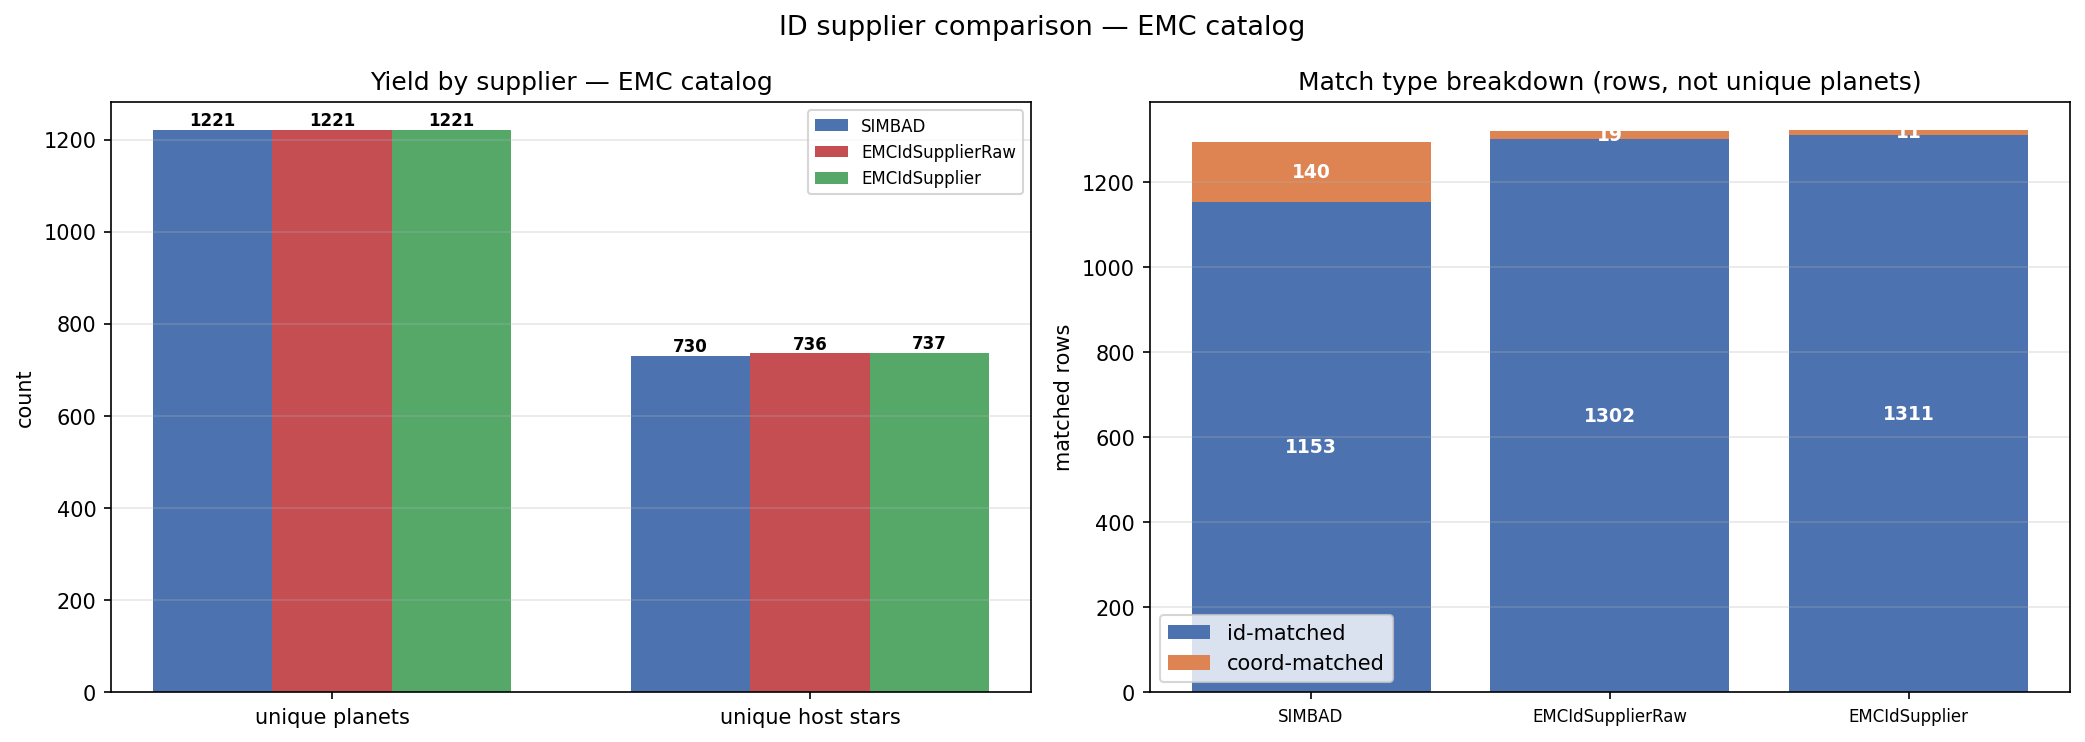

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: unique planets and host stars by supplier ───────────────────────────
ax = axes[0]
supplier_labels = ['SIMBAD', 'EMCIdSupplierRaw', 'EMCIdSupplier']
colors          = ['#4C72B0', '#C44E52', '#55A868']
metrics = ['unique planets', 'unique host stars']
x = np.arange(len(metrics))
w = 0.25
for i, (label, color) in enumerate(zip(supplier_labels, colors)):
    vals = [df.loc[label, m] for m in metrics]
    bars = ax.bar(x + (i - 1) * w, vals, w, label=label, color=color)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 1, str(v),
                ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel('count')
ax.set_title('Yield by supplier — EMC catalog')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# ── Right: stacked id vs coord rows ───────────────────────────────────────────
ax = axes[1]
x2 = np.arange(len(supplier_labels))
id_counts    = [df.loc[s, 'id-matched rows']    for s in supplier_labels]
coord_counts = [df.loc[s, 'coord-matched rows'] for s in supplier_labels]
b1 = ax.bar(x2, id_counts,    label='id-matched',    color='#4C72B0')
b2 = ax.bar(x2, coord_counts, bottom=id_counts,      label='coord-matched', color='#DD8452')
for bar, v in zip(b1, id_counts):
    ax.text(bar.get_x() + bar.get_width()/2, v/2, str(v),
            ha='center', va='center', fontsize=9, color='white')
for bar, base, v in zip(b2, id_counts, coord_counts):
    ax.text(bar.get_x() + bar.get_width()/2, base + v/2, str(v),
            ha='center', va='center', fontsize=9, color='white')
ax.set_xticks(x2); ax.set_xticklabels(supplier_labels, fontsize=8)
ax.set_ylabel('matched rows')
ax.set_title('Match type breakdown (rows, not unique planets)')
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.suptitle('ID supplier comparison — EMC catalog', fontsize=13)
plt.tight_layout()
plt.show()

In [26]:
# Planets found by EMCIdSupplier but not SIMBAD — the main gain from offline aliases
emc_exclusive = emc_id_planets - simbad_id_planets
if emc_exclusive:
    rows = cm_emc_emc.id_matched[
        np.isin([str(p) for p in cm_emc_emc.id_matched[uuid_emc]], list(emc_exclusive))
    ]
    print(f'Planets found only by EMCIdSupplier ({len(emc_exclusive)}):')
    display(rows[[uuid_emc, 'star_name', 'host']].to_pandas().drop_duplicates().head(20))

# After the whitespace + Gaia-case fix, SIMBAD should find no planets that EMC misses.
simbad_exclusive = simbad_id_planets - emc_id_planets
print(f'\nPlanets found only by SIMBAD (expect 0 after fix): {len(simbad_exclusive)}')

Planets found only by EMCIdSupplier (121):


,exo-mercat_name,star_name,host
0,* alf Tau b,TIC 245873777,Aldebaran
2,* alf Tau c,TIC 245873777,Aldebaran
3,* alf Cen A b,TIC 471011144,alf Cen
4,* alf Cen B b,TIC 471011144,alf Cen
5,* alf Cen B c,TIC 471011144,alf Cen
6,* alf Cen A b,TIC 471011145,alf Cen
7,* alf Cen B b,TIC 471011145,alf Cen
8,* alf Cen B c,TIC 471011145,alf Cen
9,HD 95735 b,TIC 353969903,Lalande 21185
10,HD 95735 c,TIC 353969903,Lalande 21185



Planets found only by SIMBAD (expect 0 after fix): 0


## NEA catalog: SimbadIdSupplier as reference

NEA + SIMBAD is the primary crossmatch pipeline. Shown here for context — EMC catalog coverage and the yield of EMCIdSupplier relative to it.

In [27]:
# NEA + SimbadIdSupplier (primary pipeline)
cm_nea = Crossmatcher(NEACatalog(), SimbadIdSupplier())
cm_nea.load_catalog(from_file='./input/pscomppars.txt', format='ascii')
cm_nea.load_alternate_ids(name_list, from_file='./alternate_ids_hpic.txt')
out_nea = cm_nea.combined_crossmatch(input_table, input_starname_key='star_name')

print('Done')

Done


In [28]:
uuid_nea = 'pl_name'

all_rows = [
    yield_summary(out_nea,         'NEA + SIMBAD',        uuid_nea),
    yield_summary(out_emc_simbad,  'EMC + SIMBAD',        uuid_emc),
    yield_summary(out_emc_raw,     'EMC + EMCIdSupplierRaw', uuid_emc),
    yield_summary(out_emc_emc,     'EMC + EMCIdSupplier', uuid_emc),
]
full_df = pd.DataFrame(all_rows).set_index('supplier')
display(full_df)

,rows,unique planets,unique host stars,id-matched rows,coord-matched rows
supplier,,,,,
NEA + SIMBAD,857,851,535,805,52
EMC + SIMBAD,1293,1221,730,1153,140
EMC + EMCIdSupplierRaw,1321,1221,736,1302,19
EMC + EMCIdSupplier,1322,1221,737,1311,11


In [29]:
# EMC planet names use a different namespace than NEA, so direct set comparison
# requires mapping via nasa_name where available.
nea_planets  = set(out_nea[uuid_nea].tolist())
emc_s_planets = set(out_emc_simbad[uuid_emc].tolist())
emc_e_planets = set(out_emc_emc[uuid_emc].tolist())

# Map EMC planets to their nasa_name equivalents for overlap with NEA
emc_catalog = cm_emc_emc.catalog_table
emc_to_nea = {
    str(row['exo-mercat_name']): str(row['nasa_name'])
    for row in emc_catalog
    if str(row['nasa_name']) not in ('', '--', 'nan')
}

emc_e_nea_names = {emc_to_nea[p] for p in emc_e_planets if p in emc_to_nea}
only_in_emc_emc = emc_e_nea_names - nea_planets
only_in_nea     = nea_planets - emc_e_nea_names
in_both         = emc_e_nea_names & nea_planets

print(f'NEA + SIMBAD unique planets:               {len(nea_planets):4d}')
print(f'EMC + EMCIdSupplier (mapped to NEA names): {len(emc_e_nea_names):4d}')
print(f'  Shared with NEA:                         {len(in_both):4d}')
print(f'  Only in EMC+EMCIdSupplier:               {len(only_in_emc_emc):4d}')
print(f'  Only in NEA+SIMBAD:                      {len(only_in_nea):4d}')

NEA + SIMBAD unique planets:                851
EMC + EMCIdSupplier (mapped to NEA names):  834
  Shared with NEA:                          831
  Only in EMC+EMCIdSupplier:                  3
  Only in NEA+SIMBAD:                        20


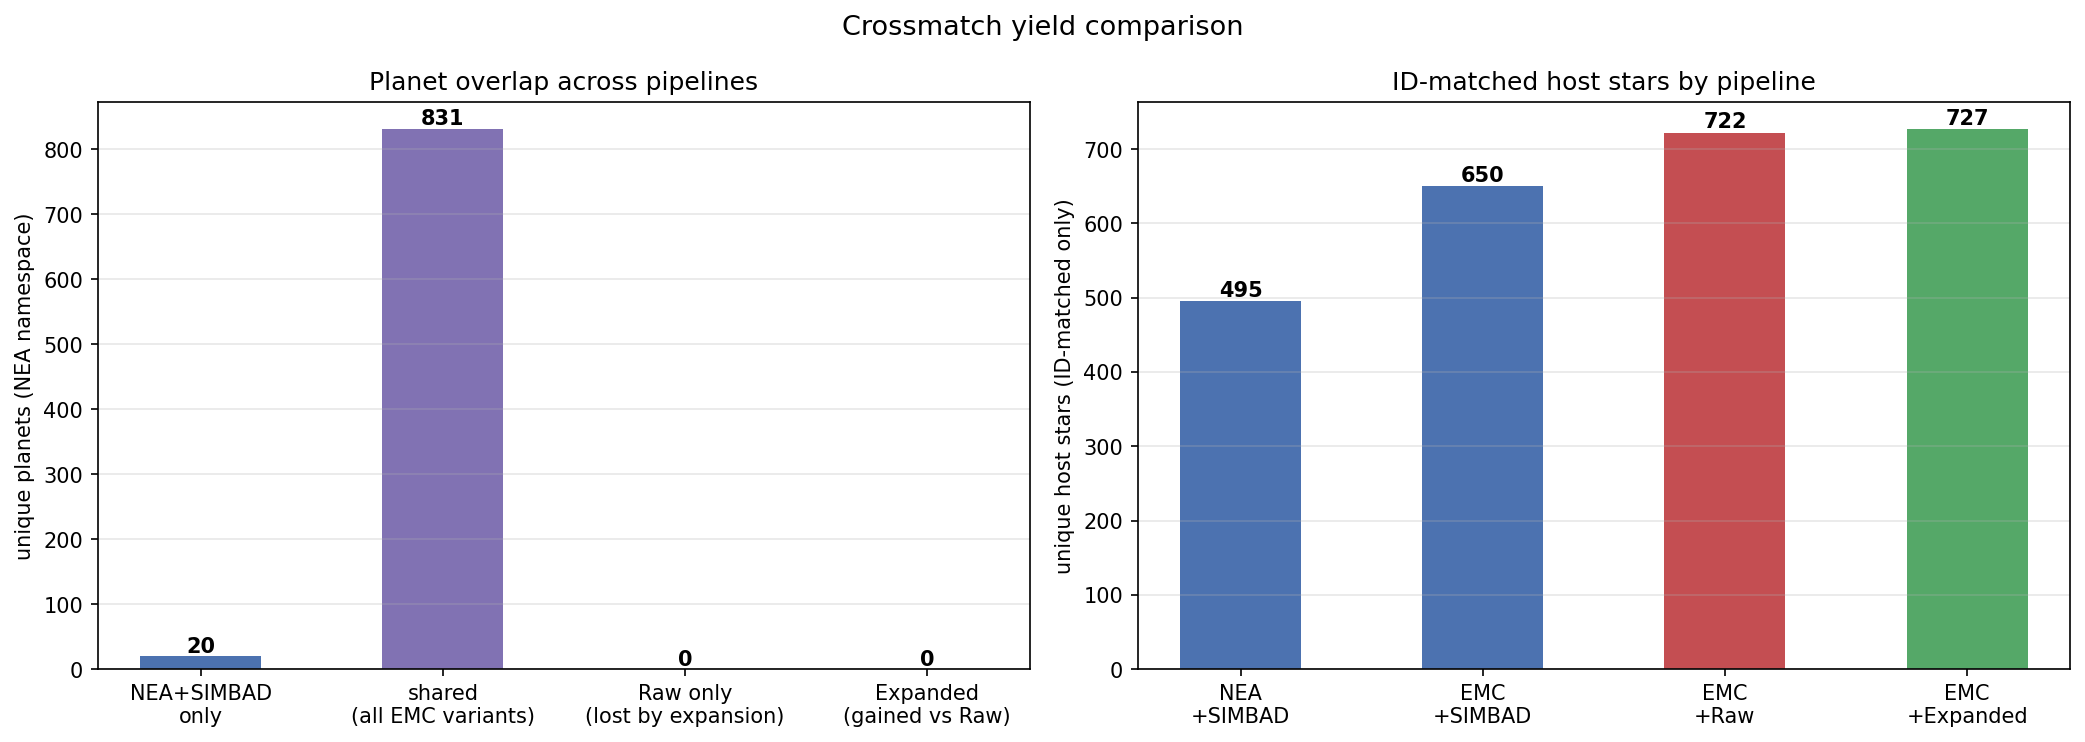

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: EMC supplier variants vs NEA+SIMBAD planet overlap (NEA namespace) ──
raw_id_planets_mapped = {emc_to_nea[p] for p in raw_id_planets if p in emc_to_nea}
# combine with coord matches for total EMC raw yield
emc_raw_all_planets = set(out_emc_raw[uuid_emc].tolist())
emc_raw_nea_names   = {emc_to_nea[p] for p in emc_raw_all_planets if p in emc_to_nea}
emc_emc_nea_names   = {emc_to_nea[p] for p in set(out_emc_emc[uuid_emc].tolist()) if p in emc_to_nea}

ax = axes[0]
groups = [
    ('NEA+SIMBAD\nonly',            nea_planets - emc_emc_nea_names,               '#4C72B0'),
    ('shared\n(all EMC variants)',   nea_planets & emc_raw_nea_names & emc_emc_nea_names, '#8172B3'),
    ('Raw only\n(lost by expansion)', emc_raw_nea_names - emc_emc_nea_names - nea_planets, '#C44E52'),
    ('Expanded\n(gained vs Raw)',    emc_emc_nea_names - emc_raw_nea_names,          '#55A868'),
]
cats   = [g[0] for g in groups]
vals   = [len(g[1]) for g in groups]
colors = [g[2] for g in groups]
bars = ax.bar(cats, vals, color=colors, width=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3, str(v),
            ha='center', va='bottom', fontsize=10)
ax.set_ylabel('unique planets (NEA namespace)')
ax.set_title('Planet overlap across pipelines')
ax.grid(axis='y', alpha=0.3)

# ── Right: id-matched host stars for all four pipelines ───────────────────────
ax = axes[1]
pipe_labels = ['NEA\n+SIMBAD', 'EMC\n+SIMBAD', 'EMC\n+Raw', 'EMC\n+Expanded']
id_host_counts = [
    len(set(cm_nea.id_matched['star_name'].tolist())),
    len(set(cm_emc_simbad.id_matched['star_name'].tolist())),
    len(set(cm_emc_raw.id_matched['star_name'].tolist())),
    len(set(cm_emc_emc.id_matched['star_name'].tolist())),
]
pipe_colors = ['#4C72B0', '#4C72B0', '#C44E52', '#55A868']
bars = ax.bar(pipe_labels, id_host_counts, color=pipe_colors, width=0.5)
for bar, v in zip(bars, id_host_counts):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, str(v),
            ha='center', va='bottom', fontsize=10)
ax.set_ylabel('unique host stars (ID-matched only)')
ax.set_title('ID-matched host stars by pipeline')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Crossmatch yield comparison', fontsize=13)
plt.tight_layout()
plt.show()